C:\Users\diego\AppData\Local\Temp\ipykernel_19380\184919256.py:3: DtypeWarning: Columns (0: photos_count, 1: latitude, 2: longitude, 3: guests, 4: bedrooms, 5: beds, 6: baths, 7: min_nights, 8: l90d_revpar_native, 9: l90d_adjusted_revpar, 10: l90d_adjusted_revpar_native, 11: l90d_reserved_days, 12: l90d_blocked_days, 13: l90d_available_days, 14: l90d_total_days) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb_data.csv", on_bad_lines="skip")


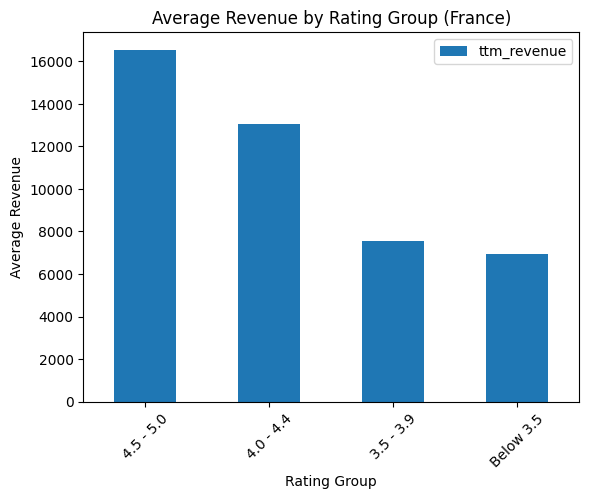

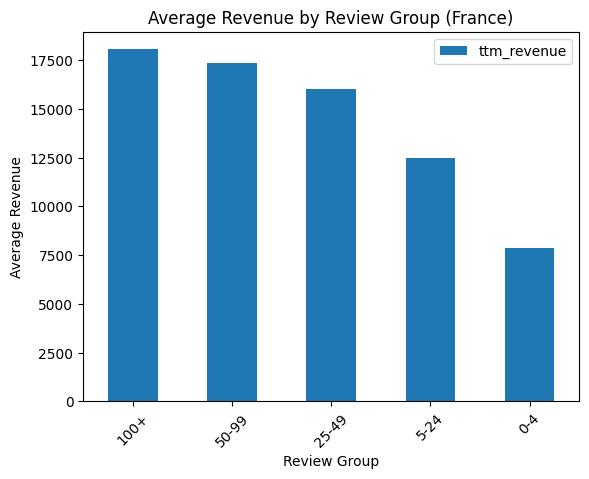

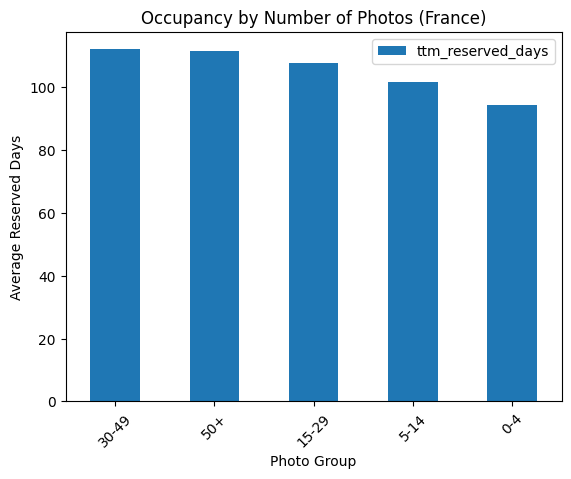

,room_type,mean,count
0,entire_home,16888.928543,22265
1,private_room,6855.846752,2571


In [ ]:
import pandas as pd

df = pd.read_csv("airbnb_data.csv", on_bad_lines="skip")

df.columns = df.columns.str.strip().str.lower()

df_fr = df[df["country"] == "France"].copy()


### Rating vs Revenue Analysis Listings with higher ratings generate significantly more revenue. 
### Properties rated 4.5+ earn more than twice the revenue compared to those below 4.0, highlighting the importance of customer satisfaction in driving profitability.
def rating_group(r):
    if r >= 4.5:
        return "4.5 - 5.0"
    elif r >= 4.0:
        return "4.0 - 4.4"
    elif r >= 3.5:
        return "3.5 - 3.9"
    else:
        return "Below 3.5"

df_fr["rating_group"] = df_fr["rating_value"].apply(rating_group)

rating_analysis = (
    df_fr.groupby("rating_group")["ttm_revenue"]
    .mean()
    .reset_index()
    .sort_values(by="ttm_revenue", ascending=False)
)

rating_analysis

import matplotlib.pyplot as plt

rating_analysis.plot(
    x="rating_group",
    y="ttm_revenue",
    kind="bar"
)

plt.title("Average Revenue by Rating Group (France)")
plt.xlabel("Rating Group")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)

plt.show()


### Reviews vs Revenue 
### Listings with a higher number of reviews generate significantly more revenue, suggesting that social proof and customer trust play a critical role in driving bookings and overall profitability.
def review_group(r):
    if r >= 100:
        return "100+"
    elif r >= 50:
        return "50-99"
    elif r >= 25:
        return "25-49"
    elif r >= 5:
        return "5-24"
    else:
        return "0-4"

df_fr["review_group"] = df_fr["num_reviews"].apply(review_group)

review_analysis = (
    df_fr.groupby("review_group")["ttm_revenue"]
    .mean()
    .reset_index()
    .sort_values(by="ttm_revenue", ascending=False)
)

review_analysis

import matplotlib.pyplot as plt

review_analysis.plot(
    x="review_group",
    y="ttm_revenue",
    kind="bar"
)

plt.title("Average Revenue by Review Group (France)")
plt.xlabel("Review Group")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)

plt.show()


### Photos VS Occupancy 
### Listings with 30–49 photos achieve the highest occupancy rates, suggesting that there is an optimal number of images that maximizes user engagement without overwhelming potential guests.
df_fr["photos_count"] = pd.to_numeric(df_fr["photos_count"], errors="coerce")
def photo_group(p):
    if p >= 50:
        return "50+"
    elif p >= 30:
        return "30-49"
    elif p >= 15:
        return "15-29"
    elif p >= 5:
        return "5-14"
    else:
        return "0-4"
    
df_fr["photo_group"] = df_fr["photos_count"].apply(photo_group)

photo_analysis = (
    df_fr.groupby("photo_group")["ttm_reserved_days"]
    .mean()
    .reset_index()
    .sort_values(by="ttm_reserved_days", ascending=False)
)

photo_analysis

import matplotlib.pyplot as plt

photo_analysis.plot(
    x="photo_group",
    y="ttm_reserved_days",
    kind="bar"
)

plt.title("Occupancy by Number of Photos (France)")
plt.xlabel("Photo Group")
plt.ylabel("Average Reserved Days")
plt.xticks(rotation=45)

plt.show()


### Room type VS Revenue
###Entire homes consistently outperform private rooms in revenue, highlighting a clear preference for privacy and complete accommodation experiences among Airbnb users.
room_analysis = (
    df_fr[df_fr["room_type"].isin(["private_room", "entire_home"])]
    .groupby("room_type")["ttm_revenue"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)

room_analysis